# Pilot 2 — real reference list

Same pilot, one change: instead of five tags typed by hand, we use the canonical
community pool list (149 coinbase-tag patterns) and watch the *unknown* bar
collapse. Along the way you'll meet the three things that make attribution hard —
and that the rest of your pipeline exists to handle.

Run top to bottom like before. Same `PROJECT_ID` as the first pilot.

In [2]:
%matplotlib inline
import json, os, urllib.request
import pandas as pd
import matplotlib.pyplot as plt
from google.cloud import bigquery

PROJECT_ID = "project-9536b219-93fb-4fca-aac"   
client = bigquery.Client(project=PROJECT_ID)
print("BigQuery client ready:", client.project)

BigQuery client ready: project-9536b219-93fb-4fca-aac


## Step 0 — get the reference list

We download the canonical `pools.json` once into `data/raw/` and load its
`coinbase_tags` section: a map from a tag substring (e.g. `/ViaBTC/`) to a pool.

**Reproducibility note for later:** this list is maintained by volunteers and
changes over time. For the real pipeline, pin a specific version (a commit hash
or a dated snapshot) so your results stay reproducible — a moving reference list
is a silent source of drift.

In [4]:
REF_URL = "https://raw.githubusercontent.com/btccom/Blockchain-Known-Pools/master/pools.json"
REF_PATH = "../data/raw/pools.json"   # assumes you run from notebooks/

os.makedirs("../data/raw", exist_ok=True)
if not os.path.exists(REF_PATH):
    print("downloading reference list...")
    urllib.request.urlretrieve(REF_URL, REF_PATH)
pools = json.load(open(REF_PATH, encoding="utf-8"))

coinbase_tags = pools["coinbase_tags"]
# longest tag first, so the most specific match wins on nested tags
TAGS = sorted(coinbase_tags.items(), key=lambda kv: len(kv[0]), reverse=True)
print(f"loaded {len(coinbase_tags)} coinbase tags, {len(pools['payout_addresses'])} payout addresses")

loaded 149 coinbase tags, 190 payout addresses


## Step 1 — pull the same 1,000 blocks

Identical cheap query (blocks table only), with the dry-run cost check.

In [5]:
QUERY = """
SELECT number AS height, timestamp, coinbase_param
FROM `bigquery-public-data.crypto_bitcoin.blocks`
WHERE coinbase_param IS NOT NULL
ORDER BY RAND()
LIMIT 1000
"""
dry = client.query(QUERY, bigquery.QueryJobConfig(dry_run=True, use_query_cache=False))
print(f"will scan ~{dry.total_bytes_processed/1e6:.1f} MB")
blocks_df = client.query(QUERY).to_dataframe()
print("shape:", blocks_df.shape)

will scan ~131.7 MB


C:\Users\Nakis\Documents\Thesis Papers\Thesis\bitcoin-decentralisation\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


shape: (1000, 3)


## Step 2 — decode (this time keeping non-ASCII tags)

A subtlety the first pilot hid: some pools tag blocks with **non-ASCII** text —
F2Pool's main tags are Chinese characters and a fish emoji. The first pilot's
ASCII decode turned those into `.` and would miss them entirely. So for *matching*
we decode as UTF-8 (keeps every tag); we keep a printable version only for
human eyeballing.

In [6]:
def decode_coinbase(hex_str):
    """hex -> UTF-8 text, keeping Chinese/emoji pool tags."""
    if not hex_str:
        return ""
    try:
        return bytes.fromhex(hex_str).decode("utf-8", errors="ignore")
    except (ValueError, TypeError):
        return str(hex_str)

def printable(hex_str):
    """hex -> ASCII with non-printable bytes as '.', for human reading only."""
    if not hex_str:
        return ""
    try:
        raw = bytes.fromhex(hex_str)
    except (ValueError, TypeError):
        return str(hex_str)
    return "".join(chr(b) if 32 <= b < 127 else "." for b in raw)

blocks_df["coinbase_text"] = blocks_df["coinbase_param"].apply(decode_coinbase)
blocks_df["coinbase_ascii"] = blocks_df["coinbase_param"].apply(printable)

## Step 3 — match against the full list

Case-sensitive substring match (the list deliberately includes case variants like
`/Huobi/` and `/HuoBi/`, so we respect case). When a tag is nested inside a longer
one — `/ViaBTC/` inside `/ViaBTC/TATMAS Pool/` — the **longest** match wins, and we
flag the block as *ambiguous*. That ambiguous flag is a preview of the
HIGH / AMBIGUOUS / UNKNOWN confidence scheme you'll build next.

In [7]:
def match_pool(text):
    """Return (pool_name, is_ambiguous)."""
    hits = [(tag, meta["name"]) for tag, meta in TAGS if tag in text]
    if not hits:
        return "unknown", False
    distinct = {name for _, name in hits}
    return hits[0][1], (len(distinct) > 1)   # hits sorted longest-first

res = blocks_df["coinbase_text"].apply(match_pool)
blocks_df["pool"] = [r[0] for r in res]
blocks_df["ambiguous"] = [r[1] for r in res]

counts = blocks_df["pool"].value_counts()
unknown_share = counts.get("unknown", 0) / len(blocks_df)
n_ambiguous = int(blocks_df["ambiguous"].sum())

print(counts.head(15).to_string())
print(f"\n... {len(counts)} distinct pools total")
print(f"unknown: {unknown_share:.1%}   (was ~70% with 5 hand-typed tags)")
print(f"ambiguous (multiple pools matched): {n_ambiguous} blocks")

pool
unknown         314
F2Pool          106
AntPool          96
Foundry USA      89
BTC Guild        47
ViaBTC           42
Braiins Pool     38
Poolin           29
CloverPool       29
BTCC             24
Binance Pool     19
Eligius          17
BTC.TOP          15
Huobi.pool       14
MARA Pool        13

... 49 distinct pools total
unknown: 31.4%   (was ~70% with 5 hand-typed tags)
ambiguous (multiple pools matched): 0 blocks


## Step 4 — Nakamoto coefficient, both treatments

In [8]:
def nakamoto_coefficient(entity_counts):
    shares = pd.Series(entity_counts).sort_values(ascending=False)
    total = shares.sum()
    if total == 0:
        return 0
    cum = 0
    for i, (_e, n) in enumerate(shares.items(), start=1):
        cum += n
        if cum / total > 0.5:
            return i
    return len(shares)

nak_incl  = nakamoto_coefficient(counts)
nak_known = nakamoto_coefficient(counts.drop("unknown", errors="ignore"))
print(f"Nakamoto, unknown as one entity (U1): {nak_incl}")
print(f"Nakamoto, unknown excluded      (U2): {nak_known}")

Nakamoto, unknown as one entity (U1): 3
Nakamoto, unknown excluded      (U2): 5


## Step 5 — plot

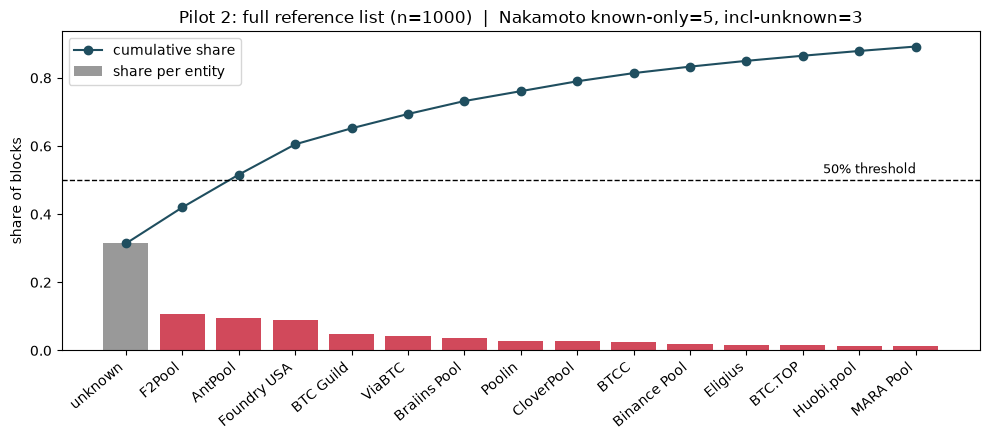

In [9]:
shares = (counts / counts.sum()).sort_values(ascending=False)
top = shares.head(15)                      # full list can have 30+ pools; show the leaders
cum = top.cumsum()

fig, ax = plt.subplots(figsize=(10, 4.5))
colors = ["#999999" if e == "unknown" else "#d1495b" for e in top.index]
ax.bar(range(len(top)), top.values, color=colors, label="share per entity")
ax.plot(range(len(top)), cum.values, "o-", color="#1f4e5f", label="cumulative share")
ax.axhline(0.5, ls="--", color="black", lw=1)
ax.text(len(top) - 1, 0.52, "50% threshold", ha="right", fontsize=9)
ax.set_xticks(range(len(top)))
ax.set_xticklabels(top.index, rotation=40, ha="right")
ax.set_ylabel("share of blocks")
ax.set_title(f"Pilot 2: full reference list (n={len(blocks_df)})  |  "
             f"Nakamoto known-only={nak_known}, incl-unknown={nak_incl}")
ax.legend()
fig.tight_layout()
os.makedirs("../figures", exist_ok=True)
fig.savefig("../figures/pilot2_shares.png", dpi=120, bbox_inches="tight")
plt.show()

## What just changed — and what you met

Compare the unknown rate to pilot 1's ~70%. The drop is entirely down to *which
reference list you use* — which is itself one of the choices your dissertation
treats as a variable, not a given.

Three things you just ran into, each tied to a piece of the project:

- **Non-ASCII tags** (F2Pool's Chinese / emoji) only matched because we decoded
  UTF-8 instead of ASCII. That decoding decision is a concrete attribution-heuristic
  choice that changes coverage — exactly the kind of thing D2 / H1–H5 capture.
- **Ambiguous blocks** (`/ViaBTC/TATMAS Pool/` matching two pools) are the
  AMBIGUOUS tier of the confidence scheme, and the host-vs-operator question is
  what operator grouping (A3 / HR1) is about.
- **Residual unknowns** are now a mix of genuinely untagged early solo blocks,
  pools missing from this list, and odd encodings. This is the floor that *payout-
  address matching* — the next step — chips away at further.

**This is still tag-only — heuristic H1.** The next real step is Stage 1 proper:
bring in the `transactions` table for payout-address matching (H2), then combine
tag + address into the HIGH / AMBIGUOUS / UNKNOWN confidence scheme. That's the
first genuine component of your pipeline, and the point where caching and the
dry-run discipline start to matter for real.

_Your observations (unknown rate now? how many ambiguous? did Nakamoto move?):_

1.
2.
